## 1. Import the SANSFitter class

In [1]:
import sys
import os

# Add parent directory to path to import sans_fitter module
sys.path.insert(0, os.path.abspath('..'))

from sans_fitter import SANSFitter
import numpy as np

# Disable OpenCL if causing issues
os.environ["HAVE_OPENCL"] = "0"
os.environ['SAS_OPEN_CL'] = "none"

## 2. Create a fitter instance and load data

In [2]:
# Initialize the fitter
fitter = SANSFitter()

# Load experimental data
fitter.load_data('../simulated_sans_data.csv')

✓ Loaded data from ../simulated_sans_data.csv
  Q range: 0.0010 to 1.0000 Å⁻¹
  Data points: 200
  Error (dI) column: yes
  Resolution (dQ) column: no


## 3. Set the model (model-agnostic!)

You can use any model from SasModels:
- 'cylinder'
- 'sphere'
- 'core_shell_sphere'
- 'ellipsoid'
- ... and many more!

In [3]:
# Load a cylinder model
fitter.set_model('cylinder')

✓ Model 'cylinder' loaded successfully
  Available parameters: 8


## 4. View available parameters

In [4]:
# Display all model parameters with their current values
fitter.get_params()


Model: cylinder
Parameter            Value        Min          Max          Vary    
--------------------------------------------------------------------------------
sld                  4            0            40           ✗       
sld_solvent          1            0            10           ✗       
radius               20           0            200          ✗       
length               400          0            4000         ✗       
theta                60           -360         360          ✗       
phi                  60           -360         360          ✗       
scale                1            0            inf          ✗       
background           0            0            inf          ✗       



## 5. Configure fitting parameters

Set initial values and ranges for the parameters you want to fit.

In [5]:
# Set parameter values and ranges
fitter.set_param('radius', value=5, min=1, max=50, vary=True)
fitter.set_param('length', value=20, min=5, max=100, vary=True)
fitter.set_param('scale', value=0.1, min=0, max=1, vary=True)
fitter.set_param('background', value=0.01, min=0, max=1, vary=True)
fitter.set_param('sld', value=2.0, min=0, max=10, vary=False)
fitter.set_param('sld_solvent', value=3.0, min=0, max=10, vary=False)

# View updated parameters
fitter.get_params()


Model: cylinder
Parameter            Value        Min          Max          Vary    
--------------------------------------------------------------------------------
sld                  2            0            10           ✗       
sld_solvent          3            0            10           ✗       
radius               5            1            50           ✓       
length               20           5            100          ✓       
theta                60           -360         360          ✗       
phi                  60           -360         360          ✗       
scale                0.1          0            1            ✓       
background           0.01         0            1            ✓       



## 6. Perform the fit using BUMPS (default engine)

In [6]:
# Fit using BUMPS with the Nelder-Mead simplex method
result = fitter.fit(engine='bumps', method='amoeba')


Initial χ² = 291.9569
Fitting with BUMPS (method: amoeba)...

✓ Fit completed!
Final χ² = 1.6555

Fitted parameters:
  background: 0.00485(13)
  length: 21.49(33)
  radius: 14.71(11)
  scale: 0.6799(49)


C:\Users\piotrrozyczko\.conda\envs\ai\Lib\site-packages\bumps\fitproblem.py:305: UserWarning: Deprecated: use of problem.fitness will be removed at some point
  warnings.warn("Deprecated: use of problem.fitness will be removed at some point")


## 7. Visualize the results

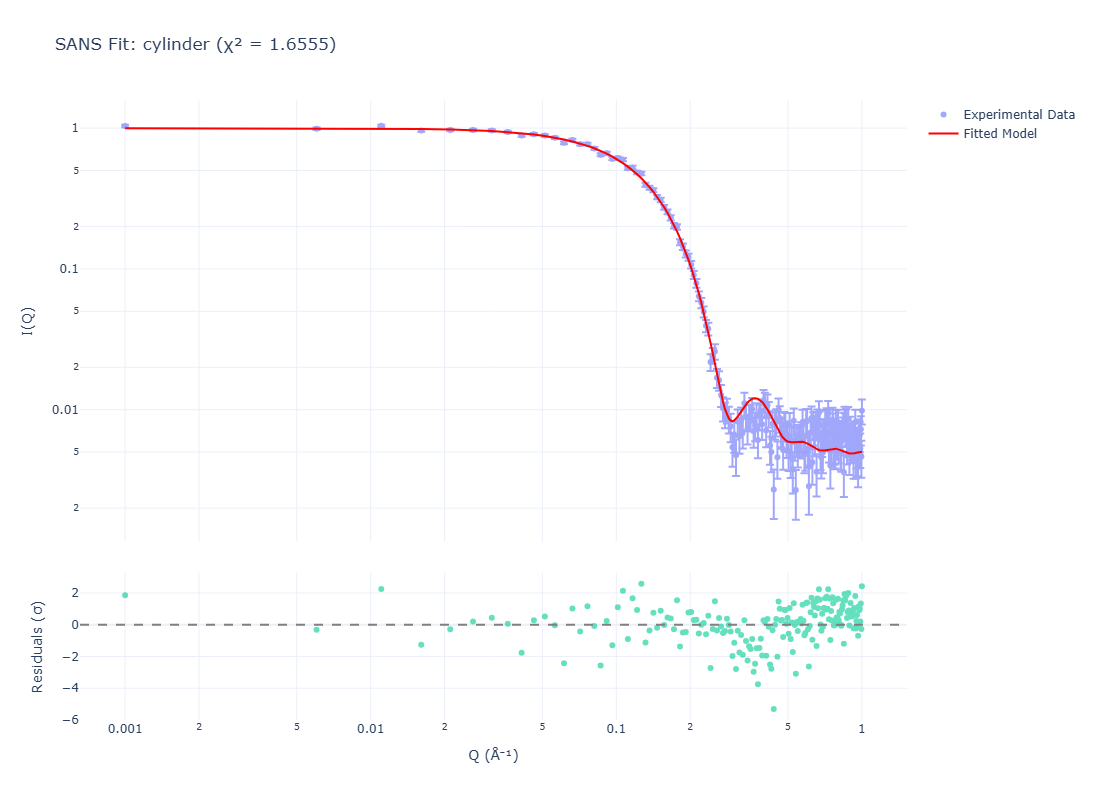

In [7]:
# Plot data vs fitted model with residuals
fitter.plot_results(show_residuals=True, log_scale=True)

## 8. Alternative: Fit using LMFit engine

You can switch to the LMFit engine for comparison.

In [8]:
# Create a new fitter instance for LMFit comparison
fitter_lm = SANSFitter()
fitter_lm.load_data('../simulated_sans_data.csv')
fitter_lm.set_model('cylinder')

# Set same parameters
fitter_lm.set_param('radius', value=5, min=1, max=50, vary=True)
fitter_lm.set_param('length', value=20, min=5, max=100, vary=True)
fitter_lm.set_param('scale', value=0.1, min=0, max=1, vary=True)
fitter_lm.set_param('background', value=0.01, min=0, max=1, vary=True)
fitter_lm.set_param('sld', value=2.0, vary=False)
fitter_lm.set_param('sld_solvent', value=3.0, vary=False)

# Fit using LMFit
result_lm = fitter_lm.fit(engine='lmfit', method='leastsq')

✓ Loaded data from ../simulated_sans_data.csv
  Q range: 0.0010 to 1.0000 Å⁻¹
  Data points: 200
  Error (dI) column: yes
  Resolution (dQ) column: no
✓ Model 'cylinder' loaded successfully
  Available parameters: 8

Fitting with scipy.optimize (method: leastsq)...

✓ Fit completed!
Final χ² = 56856.1577

Fitted parameters:
  radius: 5
  length: 20
  scale: 0.1
  background: 0.00750361
  sld: 2 (fixed)
  sld_solvent: 3 (fixed)
  theta: 60 (fixed)
  phi: 60 (fixed)


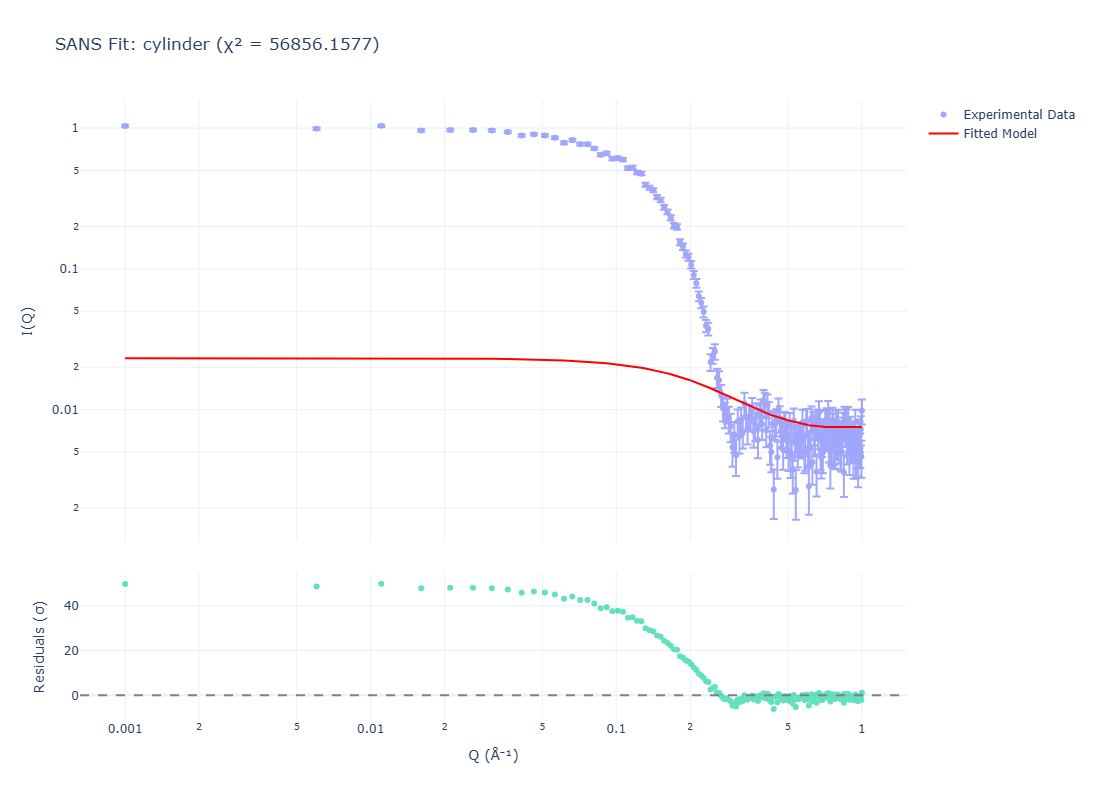

In [9]:
# Plot LMFit results
fitter_lm.plot_results(show_residuals=True, log_scale=True)

## 9. Save results to file

In [10]:
# Save fit results and fitted curve
fitter.save_results('fit_results_bumps.csv')

✓ Results saved to fit_results_bumps.csv


## 10. Try a different model (sphere)

Demonstrating the model-agnostic nature of the fitter.

In [11]:
# Create new fitter for sphere model
fitter_sphere = SANSFitter()
fitter_sphere.load_data('../simulated_sans_data.csv')
fitter_sphere.set_model('sphere')

# Check available parameters for sphere model
fitter_sphere.get_params()

✓ Loaded data from ../simulated_sans_data.csv
  Q range: 0.0010 to 1.0000 Å⁻¹
  Data points: 200
  Error (dI) column: yes
  Resolution (dQ) column: no
✓ Model 'sphere' loaded successfully
  Available parameters: 5

Model: sphere
Parameter            Value        Min          Max          Vary    
--------------------------------------------------------------------------------
sld                  1            0            10           ✗       
sld_solvent          6            0            60           ✗       
radius               50           0            500          ✗       
scale                1            0            inf          ✗       
background           0            0            inf          ✗       



In [12]:
# Configure sphere parameters
fitter_sphere.set_param('radius', value=20, min=5, max=100, vary=True)
fitter_sphere.set_param('scale', value=0.1, min=0, max=1, vary=True)
fitter_sphere.set_param('background', value=0.01, min=0, max=1, vary=True)
fitter_sphere.set_param('sld', value=2.0, vary=False)
fitter_sphere.set_param('sld_solvent', value=3.0, vary=False)

# Fit
result_sphere = fitter_sphere.fit(engine='bumps')


Initial χ² = 167.6240
Fitting with BUMPS (method: amoeba)...

✓ Fit completed!
Final χ² = 1.6589

Fitted parameters:
  background: 0.00527(13)
  radius: 15.377(40)
  scale: 0.6461(44)


C:\Users\piotrrozyczko\.conda\envs\ai\Lib\site-packages\bumps\fitproblem.py:305: UserWarning:

Deprecated: use of problem.fitness will be removed at some point



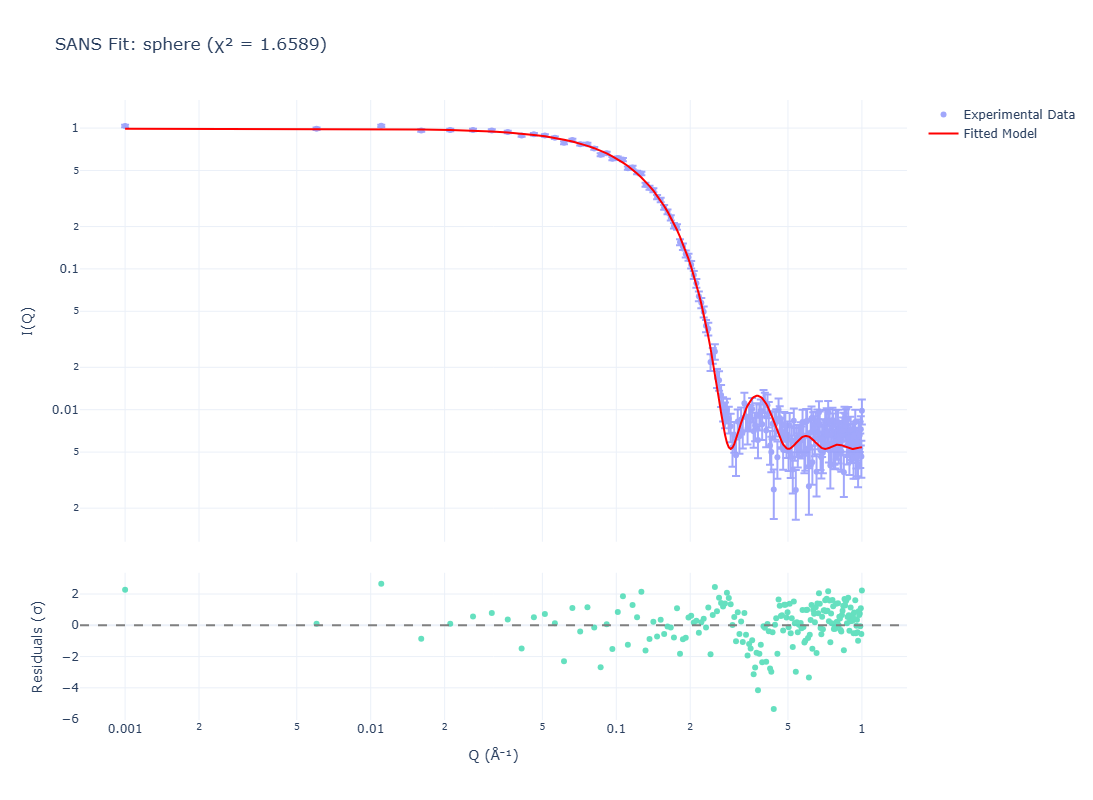

In [13]:
# Plot sphere fit results
fitter_sphere.plot_results(show_residuals=True, log_scale=True)

## Summary

The `SANSFitter` class provides:

✓ **Model-agnostic design** - Works with any SasModels model

✓ **Multiple fitting engines** - BUMPS (default) and LMFit support

✓ **User-friendly parameter management** - Easy to configure and view parameters

✓ **Flexible data loading** - Supports CSV, XML, HDF5 via sasdata

✓ **Q-range restriction** - Fit only a chosen [qmin, qmax] window; excluded points stay visible in plots

✓ **Comprehensive visualization** - Automatic plotting with residuals

✓ **Result export** - Save fitted curves and parameters to file

✓ **Polydispersity support** - Apply size distributions to model parameters
  - Multiple distribution types: gaussian, lognormal, schulz, rectangle, boltzmann
  - Easy to enable/disable globally
  - Configure independently for each polydisperse parameter

## 11. Working with Polydispersity

Polydispersity accounts for the size distribution of particles in a sample. Real experimental systems rarely have perfectly uniform particle sizes.

Key concepts:
- **pd_width**: Relative width of the size distribution (0.1 = 10%)
- **pd_type**: Distribution shape ('gaussian', 'lognormal', 'schulz', etc.)
- **pd_n**: Number of quadrature points (accuracy vs. speed tradeoff)
- **pd_nsigma**: Number of standard deviations to include

In [14]:
# Create a new fitter for polydispersity demonstration
fitter_pd = SANSFitter()
fitter_pd.load_data('../simulated_sans_data.csv')
fitter_pd.set_model('sphere')

# Check which parameters support polydispersity
print(f"Supports polydispersity: {fitter_pd.supports_polydispersity()}")
print(f"Polydisperse parameters: {fitter_pd.get_polydisperse_parameters()}")

✓ Loaded data from ../simulated_sans_data.csv
  Q range: 0.0010 to 1.0000 Å⁻¹
  Data points: 200
  Error (dI) column: yes
  Resolution (dQ) column: no
✓ Model 'sphere' loaded successfully
  Available parameters: 5
Supports polydispersity: True
Polydisperse parameters: ['radius']


In [15]:
# Configure form factor parameters
fitter_pd.set_param('radius', value=50, min=10, max=100, vary=True)
fitter_pd.set_param('sld', value=4.0, vary=False)
fitter_pd.set_param('sld_solvent', value=1.0, vary=False)
fitter_pd.set_param('scale', value=0.01, min=0.001, max=1, vary=True)
fitter_pd.set_param('background', value=0.001, min=0, max=0.1, vary=True)

# Configure 10% Gaussian polydispersity on radius
fitter_pd.set_pd_param(
    'radius',
    pd_width=0.1,       # 10% size polydispersity
    pd_type='gaussian', # Gaussian distribution
    vary=False          # Keep PD width fixed during fit
)

# Enable polydispersity globally
fitter_pd.enable_polydispersity(True)

# Display polydispersity configuration
fitter_pd.get_pd_params()


Polydispersity Status: ENABLED
Parameter       Width      N Points   N Sigma    Type         Vary    
------------------------------------------------------------------------------------------
radius          0.1        35         3          gaussian     ✗       



In [16]:
# Fit with polydispersity enabled
result_pd = fitter_pd.fit(engine='bumps', method='amoeba')
print(f"\nFitted with 10% Gaussian polydispersity on radius")


Initial χ² = 1266.1825
Fitting with BUMPS (method: amoeba)...

✓ Fit completed!
Final χ² = 1.4284

Fitted parameters:
  background: 0.00508(13)
  radius: 14.846(42)
  scale: 0.07227(52)

Fitted with 10% Gaussian polydispersity on radius


C:\Users\piotrrozyczko\.conda\envs\ai\Lib\site-packages\bumps\fitproblem.py:305: UserWarning:

Deprecated: use of problem.fitness will be removed at some point



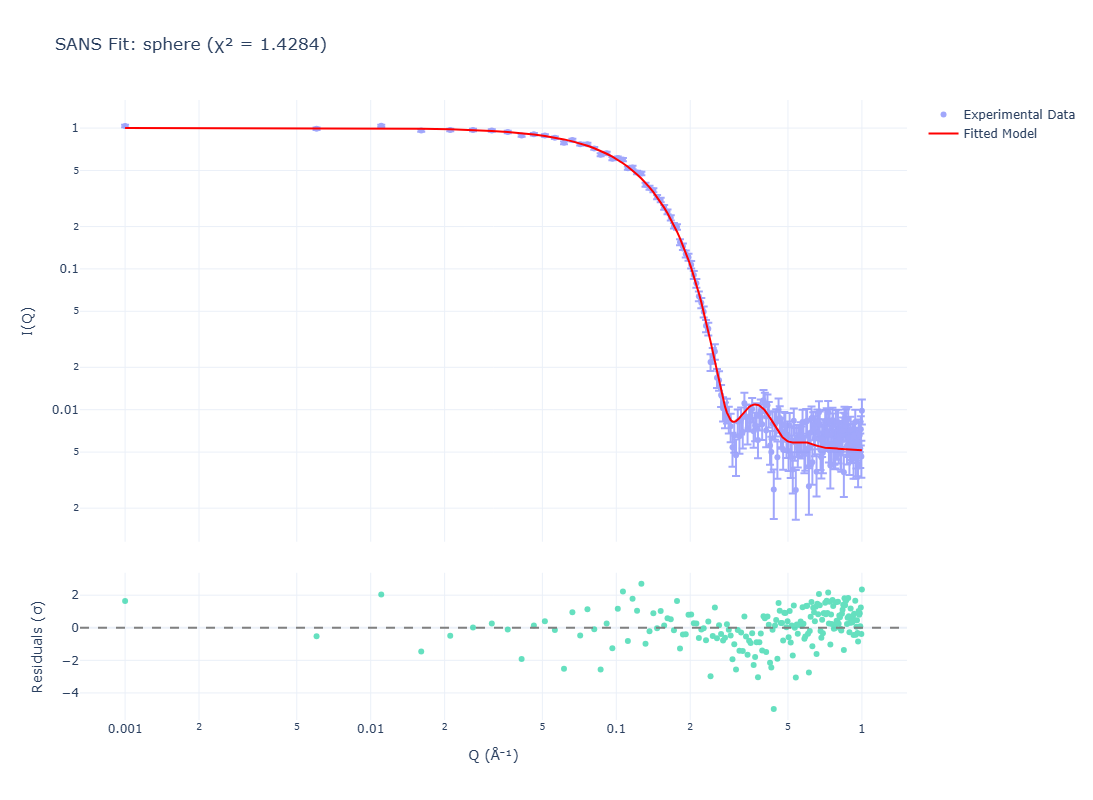

In [17]:
# Plot results with polydispersity
fitter_pd.plot_results(show_residuals=True, log_scale=True)

## 12. Comparing Distribution Types

Different distribution types may better represent your sample's size distribution.

In [18]:
# Try lognormal distribution - common for particle size distributions
fitter_lognorm = SANSFitter()
fitter_lognorm.load_data('../simulated_sans_data.csv')
fitter_lognorm.set_model('sphere')

fitter_lognorm.set_param('radius', value=50, min=10, max=100, vary=True)
fitter_lognorm.set_param('sld', value=4.0, vary=False)
fitter_lognorm.set_param('sld_solvent', value=1.0, vary=False)
fitter_lognorm.set_param('scale', value=0.01, min=0.001, max=1, vary=True)
fitter_lognorm.set_param('background', value=0.001, min=0, max=0.1, vary=True)

# Use lognormal distribution (prevents negative sizes, naturally asymmetric)
fitter_lognorm.set_pd_param('radius', pd_width=0.1, pd_type='lognormal')
fitter_lognorm.enable_polydispersity(True)

# Fit
result_lognorm = fitter_lognorm.fit(engine='bumps', method='amoeba')
print(f"Chi-squared (lognormal): {result_lognorm['chisq']:.4f}")

✓ Loaded data from ../simulated_sans_data.csv
  Q range: 0.0010 to 1.0000 Å⁻¹
  Data points: 200
  Error (dI) column: yes
  Resolution (dQ) column: no
✓ Model 'sphere' loaded successfully
  Available parameters: 5

Initial χ² = 1299.5964
Fitting with BUMPS (method: amoeba)...

✓ Fit completed!
Final χ² = 1.4304

Fitted parameters:
  background: 0.00508(13)
  radius: 14.788(42)
  scale: 0.07222(52)
Chi-squared (lognormal): 1.4304


C:\Users\piotrrozyczko\.conda\envs\ai\Lib\site-packages\bumps\fitproblem.py:305: UserWarning:

Deprecated: use of problem.fitness will be removed at some point



## 13. Polydispersity with Cylinder Model (Multiple Parameters)

For models with multiple size parameters, you can apply polydispersity to each independently.

In [19]:
# Cylinder has multiple polydisperse parameters
fitter_cyl_pd = SANSFitter()
fitter_cyl_pd.load_data('../simulated_sans_data.csv')
fitter_cyl_pd.set_model('cylinder')

# Show all polydisperse parameters for cylinder
print(f"Polydisperse parameters: {fitter_cyl_pd.get_polydisperse_parameters()}")

# Configure form factor
fitter_cyl_pd.set_param('radius', value=20, min=5, max=50, vary=True)
fitter_cyl_pd.set_param('length', value=400, min=100, max=1000, vary=True)
fitter_cyl_pd.set_param('scale', value=0.1, vary=True)
fitter_cyl_pd.set_param('background', value=0.01, vary=True)
fitter_cyl_pd.set_param('sld', value=2.0, vary=False)
fitter_cyl_pd.set_param('sld_solvent', value=3.0, vary=False)

# Apply polydispersity to BOTH radius and length
fitter_cyl_pd.set_pd_param('radius', pd_width=0.1, pd_type='gaussian')
fitter_cyl_pd.set_pd_param('length', pd_width=0.15, pd_type='gaussian')
fitter_cyl_pd.enable_polydispersity(True)

# Display all PD settings
fitter_cyl_pd.get_pd_params()

✓ Loaded data from ../simulated_sans_data.csv
  Q range: 0.0010 to 1.0000 Å⁻¹
  Data points: 200
  Error (dI) column: yes
  Resolution (dQ) column: no
✓ Model 'cylinder' loaded successfully
  Available parameters: 8
Polydisperse parameters: ['radius', 'length', 'theta', 'phi']

Polydispersity Status: ENABLED
Parameter       Width      N Points   N Sigma    Type         Vary    
------------------------------------------------------------------------------------------
radius          0.1        35         3          gaussian     ✗       
length          0.15       35         3          gaussian     ✗       
theta           0          35         3          gaussian     ✗       
phi             0          35         3          gaussian     ✗       



In [20]:
# Fit cylinder with polydispersity on both radius and length
result_cyl_pd = fitter_cyl_pd.fit(engine='bumps', method='amoeba')
print(f"\nFitted cylinder with polydispersity on radius (10%) and length (15%)")


Initial χ² = 595.3152
Fitting with BUMPS (method: amoeba)...

✓ Fit completed!
Final χ² = 85.0722

Fitted parameters:
  background: 0.00726(13)
  length: 100.0(18)
  radius: 15.64(24)
  scale: 0.1614(38)

Fitted cylinder with polydispersity on radius (10%) and length (15%)


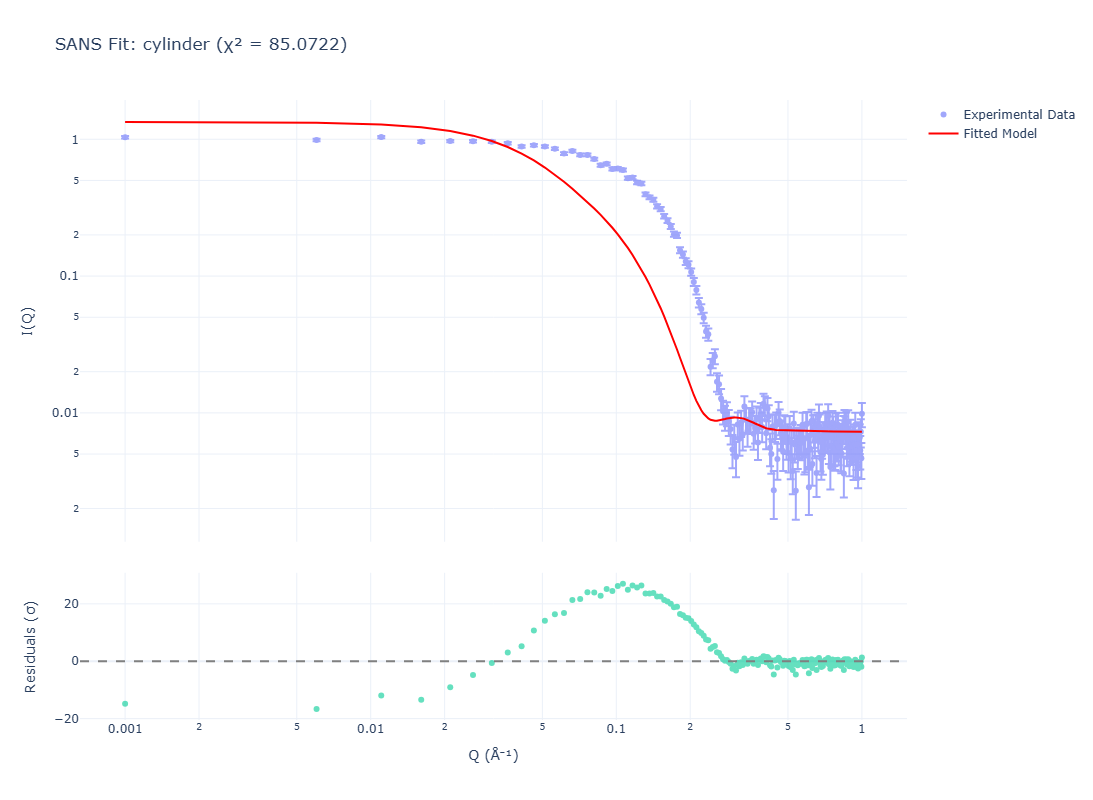

In [21]:
# Plot cylinder fit with polydispersity
fitter_cyl_pd.plot_results(show_residuals=True, log_scale=True)

## 14. Restricting the Q Range

Real datasets often contain points you do not want to fit:
- **Low Q**: beam-stop spillover or parasitic scattering
- **High Q**: points dominated by incoherent background

`set_q_range(qmin, qmax)` restricts the fit to a Q window without editing the data file:
- Both fitting engines only see points inside the window (χ² included)
- Excluded points remain visible in plots, grayed out as "Excluded Data"
- The CSV export covers only the fitted range and records the window in its header
- `get_q_range()` / `reset_q_range()` inspect and restore the range

In [22]:
# Create a fitter and restrict the Q range before fitting
fitter_qr = SANSFitter()
fitter_qr.load_data('../simulated_sans_data.csv')
fitter_qr.set_model('sphere')

fitter_qr.set_param('radius', value=20, min=5, max=100, vary=True)
fitter_qr.set_param('scale', value=0.1, min=0, max=1, vary=True)
fitter_qr.set_param('background', value=0.01, min=0, max=1, vary=True)
fitter_qr.set_param('sld', value=2.0, vary=False)
fitter_qr.set_param('sld_solvent', value=3.0, vary=False)

# Fit only 0.01 <= Q <= 0.4 Å⁻¹ (trim low-Q spillover and high-Q background)
fitter_qr.set_q_range(qmin=0.01, qmax=0.4)

result_qr = fitter_qr.fit(engine='bumps', method='amoeba')

✓ Loaded data from ../simulated_sans_data.csv
  Q range: 0.0010 to 1.0000 Å⁻¹
  Data points: 200
  Error (dI) column: yes
  Resolution (dQ) column: no
✓ Model 'sphere' loaded successfully
  Available parameters: 5
✓ Q range for fitting: 0.01 to 0.4 Å⁻¹
  Points in fit: 78 of 200

Initial χ² = 398.5167
Fitting with BUMPS (method: amoeba)...

✓ Fit completed!
Final χ² = 1.8038

Fitted parameters:
  background: 0.00437(34)
  radius: 15.306(41)
  scale: 0.6528(46)


C:\Users\piotrrozyczko\.conda\envs\ai\Lib\site-packages\bumps\fitproblem.py:305: UserWarning:

Deprecated: use of problem.fitness will be removed at some point



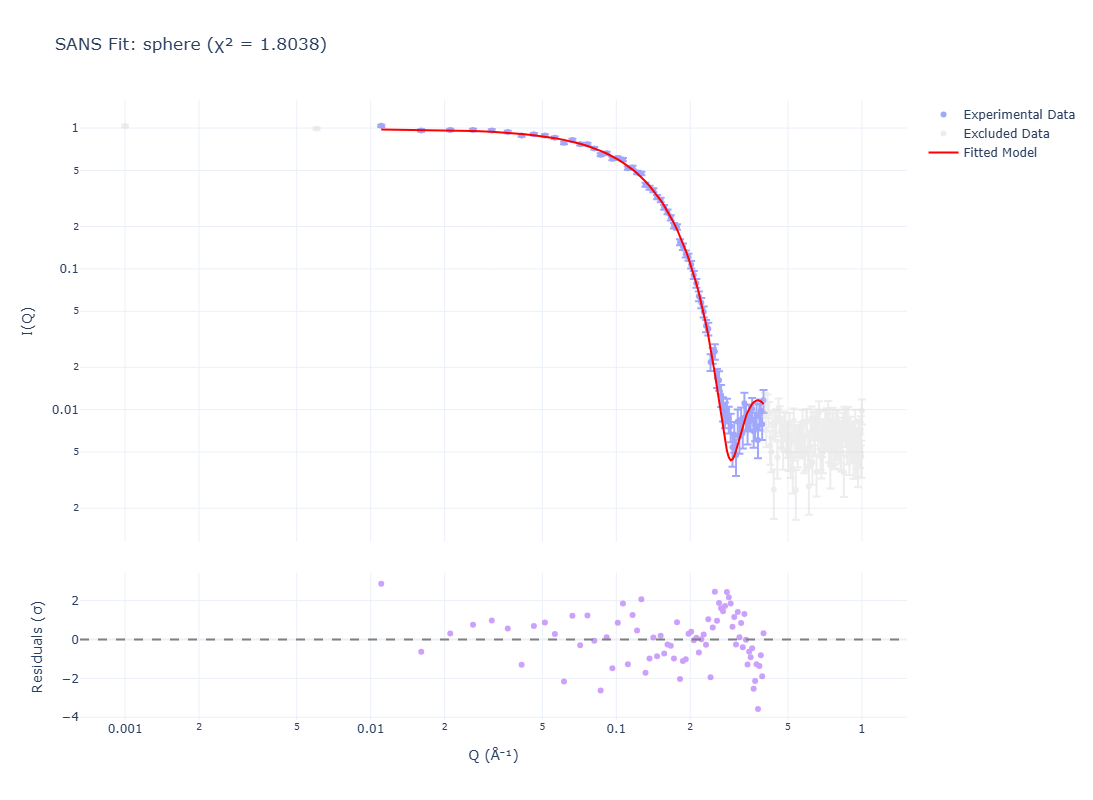

In [23]:
# Plot: the fitted curve and residuals span only the fitted window;
# points outside [0.01, 0.4] are shown grayed out as "Excluded Data"
fitter_qr.plot_results(show_residuals=True, log_scale=True)

In [24]:
# Inspect the active range, then restore the full range and refit for comparison
print(f"Current Q range: {fitter_qr.get_q_range()}")

fitter_qr.reset_q_range()
result_full = fitter_qr.fit(engine='bumps', method='amoeba')

print(f"\nχ² restricted range: {result_qr['chisq']:.4f}")
print(f"χ² full range:       {result_full['chisq']:.4f}")

Current Q range: (0.01, 0.4)
✓ Q range reset to 0.001 to 1 Å⁻¹
  Points in fit: 200

Initial χ² = 1.8976
Fitting with BUMPS (method: amoeba)...

✓ Fit completed!
Final χ² = 1.6589

Fitted parameters:
  background: 0.00527(13)
  radius: 15.377(40)
  scale: 0.6461(44)

χ² restricted range: 1.8038
χ² full range:       1.6589


C:\Users\piotrrozyczko\.conda\envs\ai\Lib\site-packages\bumps\fitproblem.py:305: UserWarning:

Deprecated: use of problem.fitness will be removed at some point



## 15. Bayesian Analysis (MCMC posterior sampling)

The Bayesian workflow — posterior sampling with `fit_bayesian()` and the associated
corner, marginal, posterior-predictive, correlation, and trace plots — now lives in
its own notebook: [bayesian_sampling.ipynb](bayesian_sampling.ipynb).